# Logistic regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

In [2]:
df = pd.read_csv('./data/hearing_test.csv')

In [ ]:
df.describe()

In [ ]:
print(df['test_result'].value_counts())

In [ ]:
sns.countplot(data=df, x='test_result')

In [ ]:
sns.scatterplot(x='age', y='physical_score', data=df, hue='test_result', alpha=0.5)

## Split into on the features/target variable and training/testing data

In [9]:
# ___ Разбиение на призначи и целевую переменную ______
X = df.drop('test_result', axis=1)
y = df['test_result']

In [12]:
# __ Разбиение данных 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [ ]:
X_train[:10]

## StandardScaler

In [22]:
# __ Масштабирование признаков
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [32]:
print(type(X_train))
print(type(scaled_X_train))

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


## Create model

In [28]:
# __ Создем модель логистической регрессии
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

## Learning model

In [29]:
# __ Обучаем модель
log_model.fit(scaled_X_train, y_train)

LogisticRegression()

In [33]:
print(log_model.coef_) # Смотрим на коэффициенты

[[-0.95017725  3.46148946]]


## Predict

In [34]:
# __ Предсказываем
y_pred = log_model.predict(scaled_X_test)

In [40]:
# y_pred - это 0 или 1, здесь вероятности
y_pred_prob = log_model.predict_proba(scaled_X_test)
y_pred_prob[:10]

array([[0.02380517, 0.97619483],
       [0.02688541, 0.97311459],
       [0.98922003, 0.01077997],
       [0.00190239, 0.99809761],
       [0.97506574, 0.02493426],
       [0.98967692, 0.01032308],
       [0.07395589, 0.92604411],
       [0.01706411, 0.98293589],
       [0.9970754 , 0.0029246 ],
       [0.03300925, 0.96699075]])

In [38]:
type(y_pred_prob)

numpy.ndarray

## Metrics

In [35]:
#  _____________ Метрики классификации: 
#  ______ Confusion Matrix и Accuracy, Precision, Recall и F1-Score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [44]:
# __________ вначале строим матрицу accuracy
confusion_resalt = confusion_matrix(y_test, y_pred)
confusion_resalt

array([[172,  21],
       [ 14, 293]], dtype=int64)

In [42]:
# __ Оцениваем Accuracy
accuracy_resalt = accuracy_score(y_test, y_pred)
print(accuracy_resalt) # (172+293)/(172+293+14+21)

0.93


In [48]:
from sklearn.metrics import precision_score, recall_score
precision_score_resalt = precision_score(y_test, y_pred)
precision_score_resalt # 172/(172+14)

0.9331210191082803

In [53]:
recall_score_resalt = recall_score(y_test, y_pred)
recall_score_resalt

0.9543973941368078

In [54]:
172/(172+14)

0.9247311827956989

In [55]:
293/(293+21)

0.9331210191082803

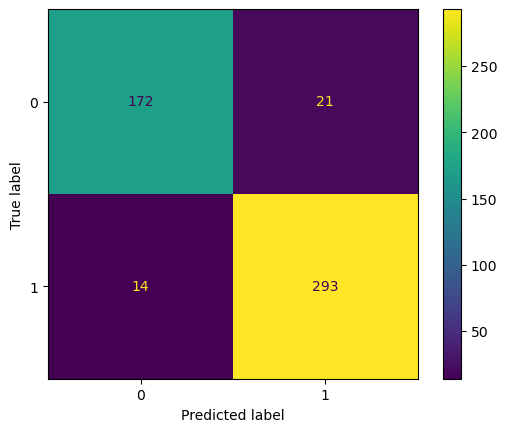

In [59]:
ConfusionMatrixDisplay.from_estimator(log_model, scaled_X_test, y_test)

In [61]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91       186
           1       0.95      0.93      0.94       314

    accuracy                           0.93       500
   macro avg       0.92      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



In [65]:
293/(293+14)

0.9543973941368078

## Поиграем с порогом

In [66]:

y_pred_probs = log_model.predict_proba(scaled_X_test)[:, 1]

In [75]:
# Установка кастомного порога (например, 0.7)
threshold_07 = 0.7
threshold_03 = 0.3
y_pred_custom_03 = (y_pred_probs > threshold_03).astype(int)
y_pred_custom_07 = (y_pred_probs > threshold_07).astype(int)

In [76]:
print('__________0.5______________')
print(classification_report(y_pred, y_test))
print('__________0.3______________')
print(classification_report(y_pred_custom_03, y_test))
print('___________0.7___________')
print(classification_report(y_pred_custom_07, y_test))

__________0.5______________
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       186
           1       0.95      0.93      0.94       314

    accuracy                           0.93       500
   macro avg       0.92      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500

__________0.3______________
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       164
           1       0.99      0.91      0.95       336

    accuracy                           0.93       500
   macro avg       0.92      0.95      0.93       500
weighted avg       0.94      0.93      0.94       500

___________0.7___________
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       212
           1       0.90      0.95      0.92       288

    accuracy                           0.91       500
   macro avg       0.91      0.90      0.91   

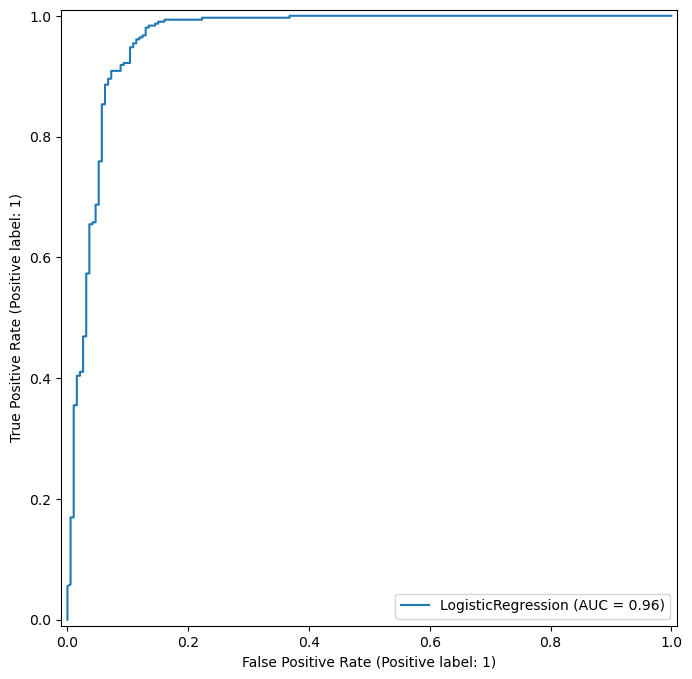

In [77]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
fig, ax = plt.subplots(figsize=(12,8))
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test, ax = ax)

# PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test, ax=ax)